In [1]:
import sys
sys.path.append('..')

In [2]:
import copy
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay

from src.model import CardinalityEstimator
from src.dataset import GalacticBinariesDataset
from config import BATCH_SIZE, MAX_K, SPLIT_SEED

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {device}") 

learning_strategy = "ordinal"
ckpt_path = Path("../runs/run_20260519_174743/checkpoints/best_checkpoint.pth")
dataset_path = Path("/sps/l2it/tdonze/gb-dataset-gen/data/synthetic_dataset/dataset_500K_variable_amp.hdf5")

Using device : cuda


In [4]:
model = CardinalityEstimator(learning_strategy="ordinal", max_K=MAX_K, input_channels=4).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

CardinalityEstimator(
  (conv_encoder): Sequential(
    (conv_1): Conv1d(4, 32, kernel_size=(8,), stride=(2,), padding=(3,))
    (gelu_1): GELU(approximate='none')
    (conv_2): Conv1d(32, 64, kernel_size=(8,), stride=(2,), padding=(3,))
    (gelu_2): GELU(approximate='none')
    (conv_3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(3,))
  )
  (pos_encoder): PosEnc()
  (MHAttention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (pooling): PoolingConcat(
    (attn): Linear(in_features=128, out_features=128, bias=True)
    (context_vec): Linear(in_features=128, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (fc_1): Linear(in_features=384, out_features=256, bias=True)
    (gelu_1): GELU(approximate='none')
    (output): Linear(in_features=256, out_features=9, bias=True)
  )
)

In [5]:
def make_dataset_view(base_ds, seed, noise):
    ds = copy.copy(base_ds)

    ds.seed = seed
    ds.noise = noise
    ds.rng = np.random.default_rng(seed)
    
    ds.fixed_mixtures = ds._build_fixed_mixtures()

    return ds

base_ds = GalacticBinariesDataset(
    dataset_path=dataset_path,
    max_K=MAX_K,
    max_samples=None,
    indices=None,
    noise=False,
    deterministic=True,
    energy_matched=False,
    return_params = True,
    seed=0
)

[05/21/26 13:58:42] INFO     Total waveforms in dataset: 524288

                    INFO     Selected 524288 waveforms for use in the dataset

                    INFO     Dataset length set to 524288 samples (max_samples=None)

                    INFO     Loading 524288 waveforms in memory...

[05/21/26 13:58:52] INFO     Waveforms loaded with shape (524288, 4, 128)

                    INFO     Loading parameters amp, beta, f0, fddot, fdot, iota, lam, phi0, psi, snr in memory...

                    INFO     Parameters loaded successfully

In [6]:
NB_RUNS = 10
seeds = [0, 2026, 45, 1234, 5678, 91011, 121314, 151617, 181920, 212223]
assert NB_RUNS == len(seeds), "NB_RUNS should be equal to len(seeds)"

all_results = []

done = False
path = Path("ordinal_evaluation_results.csv")


if path.exists():
    print(f"File {path} already exists. Loading existing results.")
    results_df = pd.read_csv(path)
    done = True

if not done :
    for run in range(NB_RUNS):
        seed = seeds[run]

        print(f"Copying dataset for run {run + 1}, seed : {seed}")
        val_ds = make_dataset_view(base_ds, seed=seed, noise=True)

        signal_ds = copy.copy(val_ds)
        signal_ds.noise = False
        print(f"Dataset copied for run {run + 1}")

        val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
        signal_loader = DataLoader(signal_ds, batch_size=4, shuffle=False)

        rows = []
        offset = 0

        with torch.no_grad():
            progress = tqdm(
                zip(val_loader, signal_loader),
                total=len(val_loader),
                desc=f"Run {run + 1}/{NB_RUNS}",
                leave=True,
            )

            for (summed_waveform, targets, params), (signal_waveform, signal_targets, signal_params) in progress:
                X = torch.as_tensor(summed_waveform, dtype=torch.float32, device=device)
                X_signal = torch.as_tensor(signal_waveform, dtype=torch.float32, device=device)

                targets = torch.as_tensor(targets, dtype=torch.long, device=device)
                signal_targets = torch.as_tensor(signal_targets, dtype=torch.long, device=device)

                assert torch.equal(targets, signal_targets)

                logits = model(X)

                if learning_strategy == "mse":
                    y = targets.float().unsqueeze(1) / MAX_K # shape : (batch_size, 1)
                    out = torch.sigmoid(logits) # shape : (batch_size, 1)

                    pred_score = out.squeeze(1) * MAX_K # shape : (batch_size,)
                    pred = torch.round(pred_score).long().clamp(1, MAX_K) # shape : (batch_size,)

                    loss_per_sample = F.mse_loss(out, y, reduction="none").squeeze(1) # shape : (batch_size,)
                elif learning_strategy == "ordinal":
                    thresholds = torch.arange(1, MAX_K, device=device) # shape3 : (max_K - 1,)
                    y = (targets.unsqueeze(1) > thresholds.unsqueeze(0)).float() # shape : (batch_size, max_K - 1)

                    probs = torch.sigmoid(logits)

                    pred = 1 + (probs > 0.5).sum(dim=1)
                    pred = pred.clamp(1, MAX_K)

                    pred_score = 1.0 + probs.sum(dim=1)

                    loss_per_sample = F.binary_cross_entropy_with_logits(
                        logits,
                        y,
                        reduction="none",
                    ).mean(dim=1) 
                elif learning_strategy == "cross_entropy":
                    y = targets - 1

                    probs = F.softmax(logits, dim=1)
                    class_values = torch.arange(1, MAX_K + 1, device=device).float()

                    pred = logits.argmax(dim=1) + 1
                    pred_score = (probs * class_values.unsqueeze(0)).sum(dim=1)

                    loss_per_sample = F.cross_entropy(logits, y, reduction="none")
                else:
                    raise ValueError(f"Unknown learning strategy : {learning_strategy}")
                
                snr = torch.as_tensor(params["snr"], dtype=torch.float32, device=device)
                source_mask = torch.as_tensor(params["source_mask"], dtype=torch.bool, device=device)

                snr_masked = torch.where(source_mask, snr, torch.zeros_like(snr))
                snr_mix = torch.sqrt((snr_masked ** 2).sum(dim=1))
                max_snr = snr_masked.max(dim=1).values
                mean_snr = snr_masked.sum(dim=1) / source_mask.sum(dim=1).clamp(min=1)

                n_visible_5 = ((snr > 5) & source_mask).sum(dim=1)
                n_visible_10 = ((snr > 10) & source_mask).sum(dim=1)
                n_visible_20 = ((snr > 20) & source_mask).sum(dim=1)

                energy_noisy = (X ** 2).sum(dim=(1, 2))
                energy_signal = (X_signal ** 2).sum(dim=(1, 2))

                batch_size = targets.shape[0]

                for i in range(batch_size):
                    valid_snr = snr[i][source_mask[i]].detach().cpu().numpy()

                    rows.append({
                        "run": run,
                        "seed": seed,
                        "idx": offset + i,

                        "true_K": int(targets[i].item()),
                        "pred_K": int(pred[i].item()),
                        "pred_score": float(pred_score[i].item()),

                        "correct": bool(pred[i].item() == targets[i].item()),
                        "error_K": int(pred[i].item() - targets[i].item()),
                        "abs_error_K": int(abs(pred[i].item() - targets[i].item())),

                        "loss": float(loss_per_sample[i].item()),

                        "snr_values": valid_snr.tolist(),
                        "snr_mix": float(snr_mix[i].item()),
                        "max_snr": float(max_snr[i].item()),
                        "mean_snr": float(mean_snr[i].item()),

                        "n_visible_5": int(n_visible_5[i].item()), # correspond to the number of sources with SNR > 5
                        "n_visible_10": int(n_visible_10[i].item()), # correspond to the number of sources with SNR > 10
                        "n_visible_20": int(n_visible_20[i].item()), # correspond to the number of sources with SNR > 20

                        "energy_noisy": float(energy_noisy[i].item()),
                        "energy_signal": float(energy_signal[i].item()),
                    })

                offset += batch_size

        df = pd.DataFrame(rows)
        all_results.append(df)
    results_df = pd.concat(all_results, ignore_index=True)
    print(f"Saving results to {path}")
    results_df.to_csv(path, index=False)

File ordinal_evaluation_results.csv already exists. Loading existing results.


In [7]:
LABELS = np.arange(1, MAX_K + 1)

def compute_metrics(df, target_col="true_K", pred_col="pred_K"):
    y_true = df[target_col].to_numpy()
    y_pred = df[pred_col].to_numpy()

    return pd.Series({
        "n": len(df),
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        "mae": mean_absolute_error(y_true, y_pred),
        "mean_error": np.mean(y_pred - y_true),
    })

#### Global Metrics Calculation and Display

In [8]:
metrics_by_run = results_df.groupby("run").apply(compute_metrics)
print("Metrics by run :")
display(metrics_by_run)
print("Mean metrics across runs :")
display(metrics_by_run.mean().rename("mean"))
print("Standard deviation of metrics across runs :")
display(metrics_by_run.std().rename("std"))

Metrics by run :


,n,acc,macro_f1,mae,mean_error
run,,,,,
0,524288.0,0.409330,0.408548,0.795498,-0.112881
1,524288.0,0.410791,0.409910,0.793777,-0.114738
2,524288.0,0.409254,0.408026,0.795353,-0.116684
3,524288.0,0.410078,0.409020,0.794731,-0.116661
4,524288.0,0.409149,0.408362,0.795149,-0.112009
5,524288.0,0.410667,0.409767,0.792669,-0.113405
6,524288.0,0.408535,0.407494,0.795904,-0.111925
7,524288.0,0.409382,0.408405,0.795198,-0.111082
8,524288.0,0.409195,0.408163,0.795658,-0.110481


Mean metrics across runs :


n             524288.000000
acc                0.409667
macro_f1           0.408688
mae                0.794749
mean_error        -0.113168
Name: mean, dtype: float64

Standard deviation of metrics across runs :


n             0.000000
acc           0.000742
macro_f1      0.000772
mae           0.001062
mean_error    0.002197
Name: std, dtype: float64

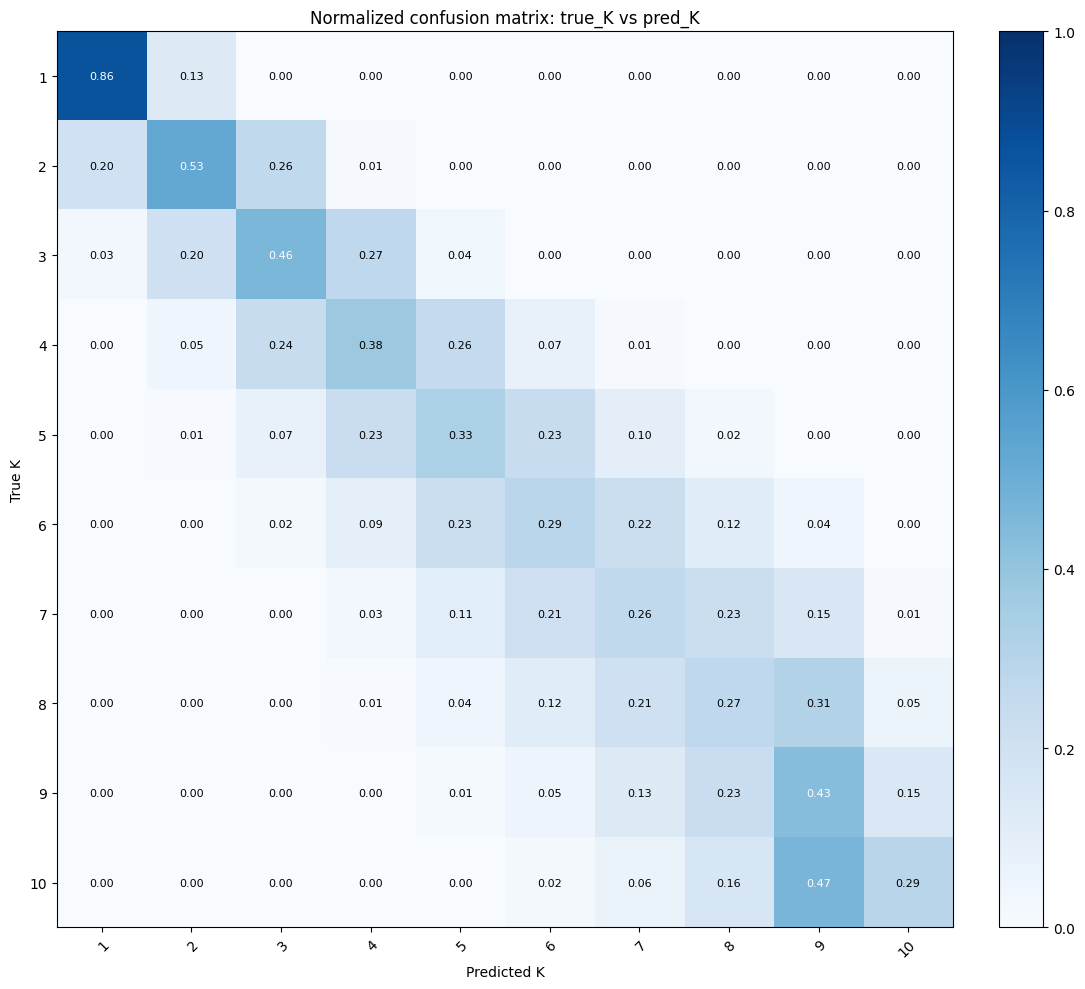

In [9]:
cm = confusion_matrix(results_df["true_K"], results_df["pred_K"], labels=LABELS)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_title("Normalized confusion matrix: true_K vs pred_K")
ax.set_xlabel("Predicted K")
ax.set_ylabel("True K")
ax.set_xticks(np.arange(len(LABELS)))
ax.set_yticks(np.arange(len(LABELS)))
ax.set_xticklabels(LABELS)
ax.set_yticklabels(LABELS)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j, i, f"{cm_norm[i, j]:.2f}",
            ha="center", va="center",
            fontsize=8,
            color="white" if cm_norm[i, j] > cm_norm.max() / 2 else "black",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#### Error Analysis based on SNR

TODO : 
- Average snr_mix per k
- Histogram of snr_mix for each k
- Histogram of snr_mix for each k and average error with this bin
- in one plot : the curve of precision relative to k, the curve of SNR relative to snr_mix

regarder quand y'a beaucoup n_visible_5, 10, 20, ce qu'il se passe.


true_K
1      31.164108
2      49.916867
3      64.349766
4      76.327912
5      86.803260
6      96.149044
7     104.705014
8     112.573147
9     120.034576
10    126.987248
Name: snr_mix, dtype: float64


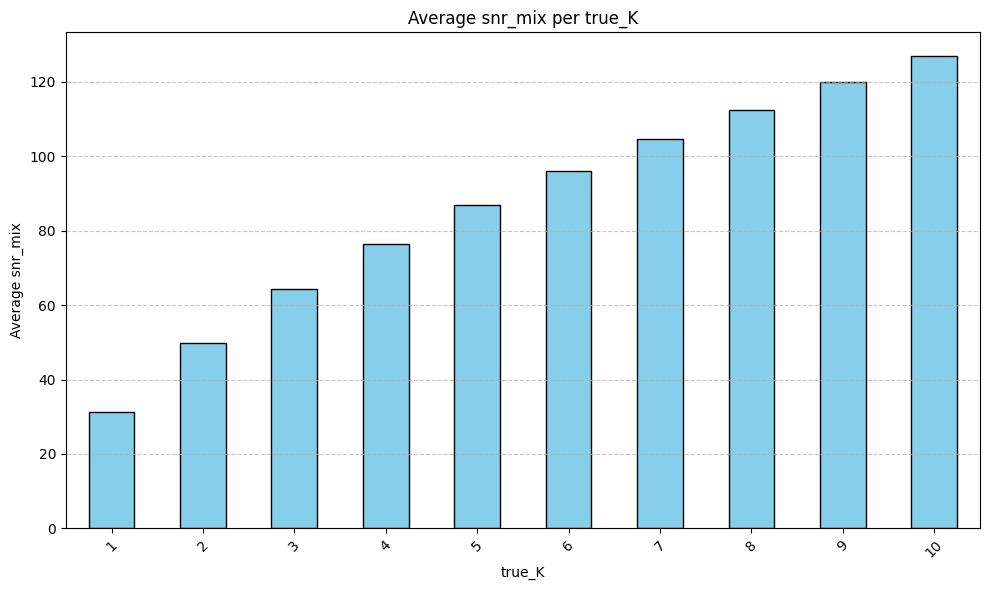

In [12]:
df_mean_snr_mix_per_k = results_df.groupby('true_K')['snr_mix'].mean()
print(df_mean_snr_mix_per_k)
plt.figure(figsize=(10, 6))
df_mean_snr_mix_per_k.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average snr_mix per true_K')
plt.xlabel('true_K')
plt.ylabel('Average snr_mix')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
def fully_print_df(df):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        print(df)

In [24]:
results_df["mae"] = abs(results_df["pred_K"] - results_df["true_K"])
results_df["accuracy"] = (results_df["pred_K"] == results_df["true_K"]).astype(int)

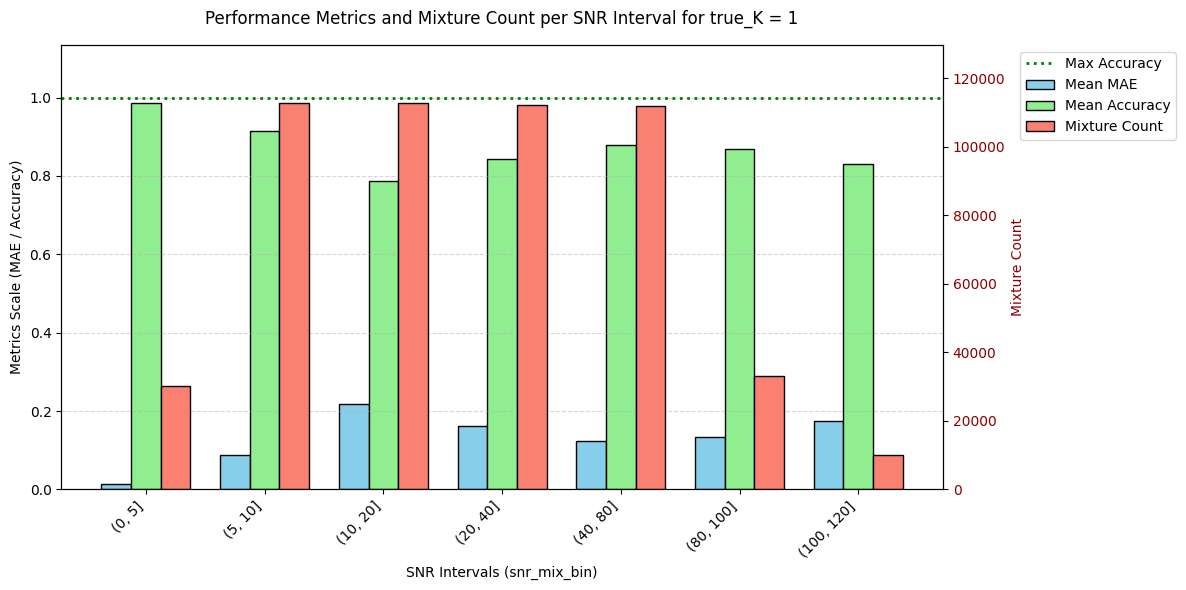

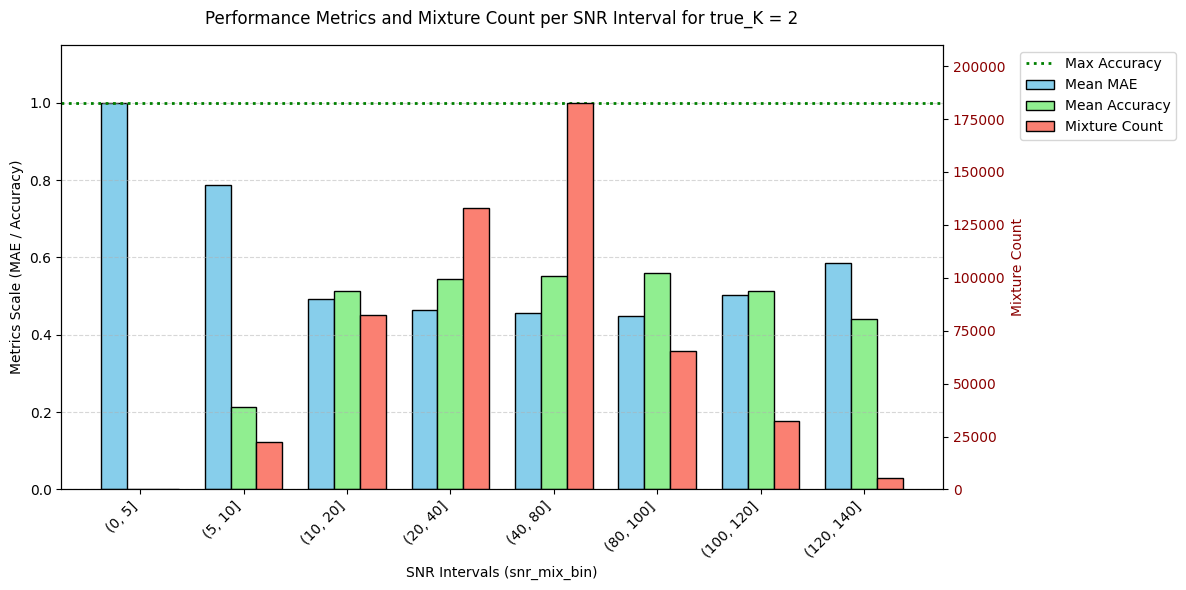

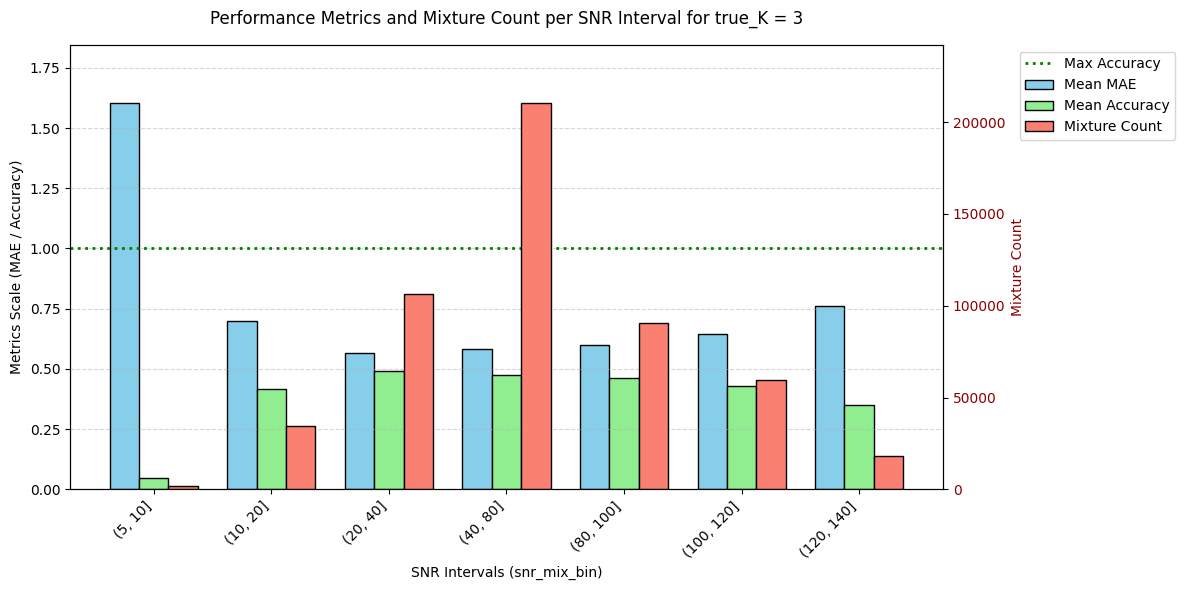

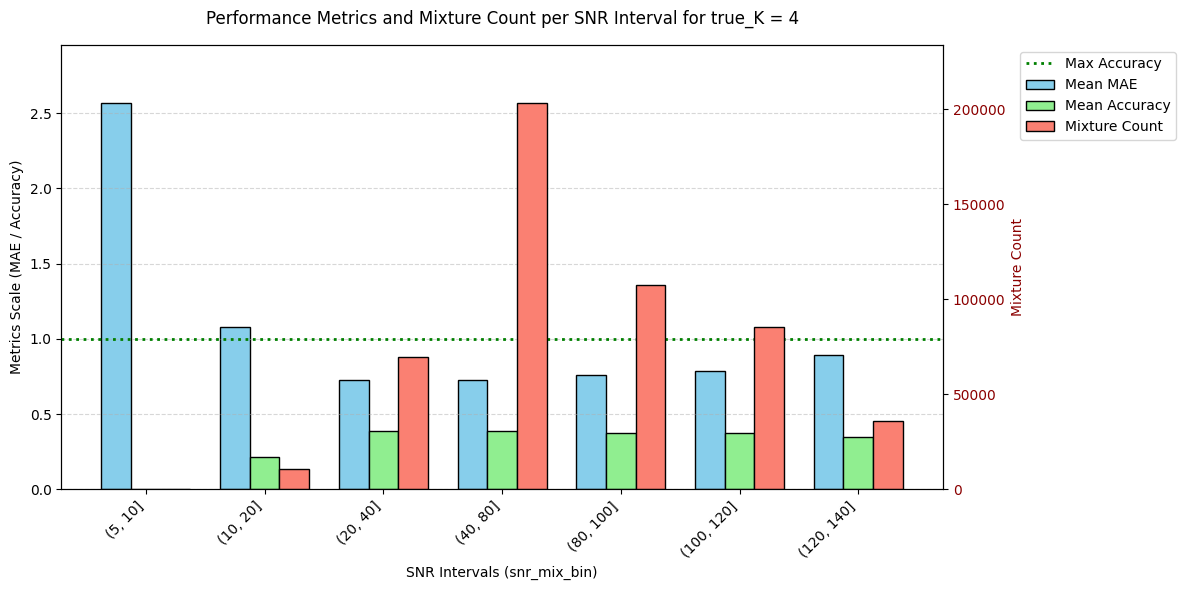

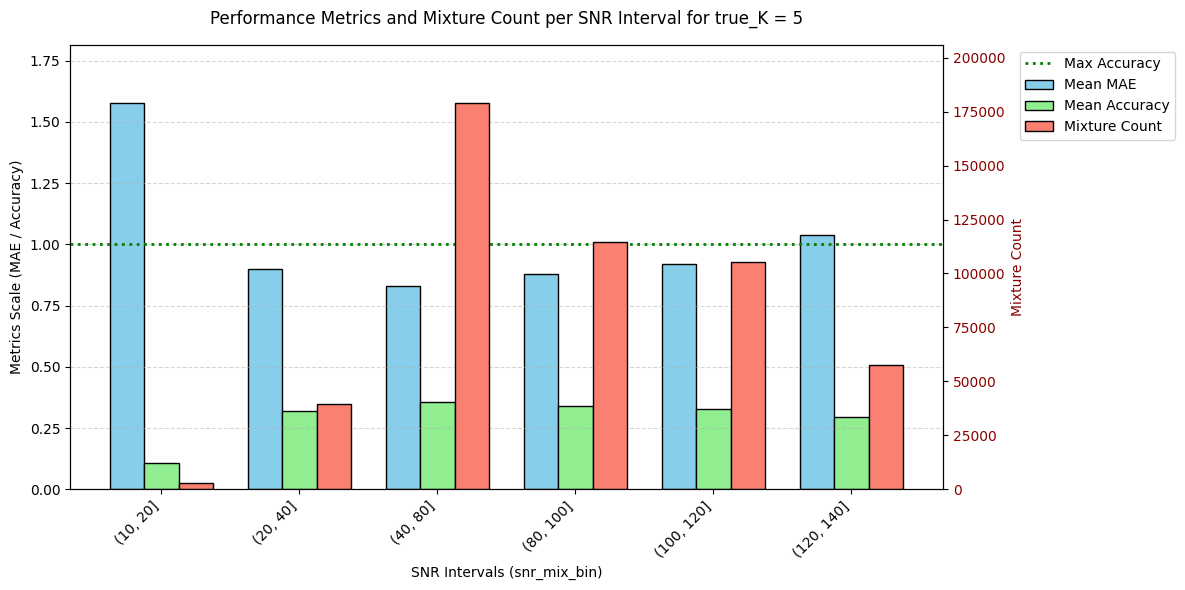

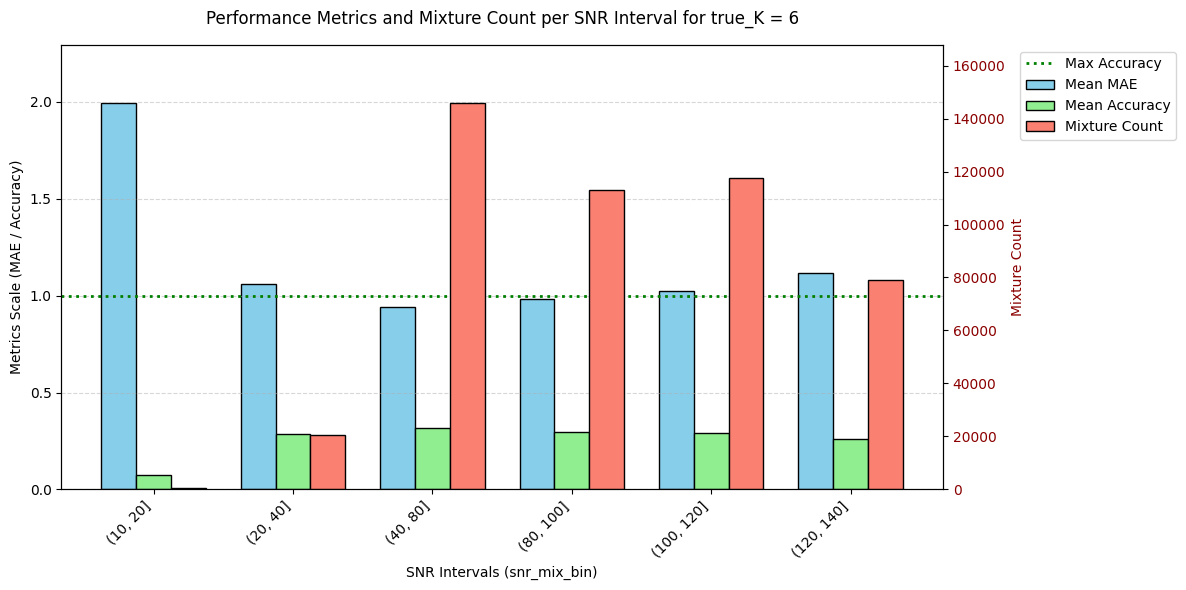

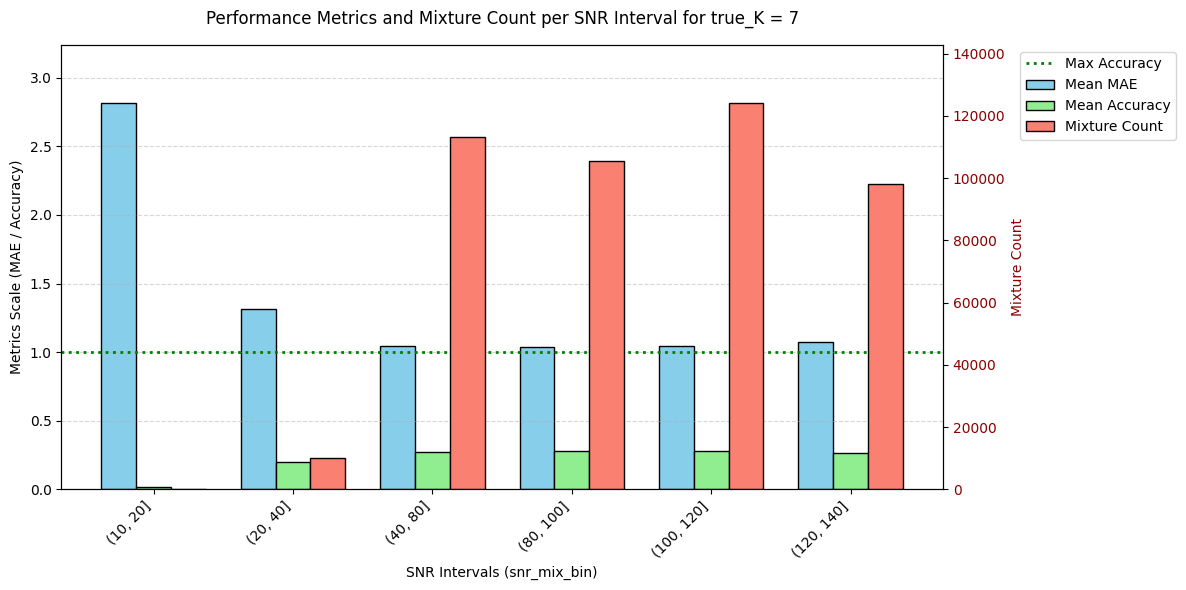

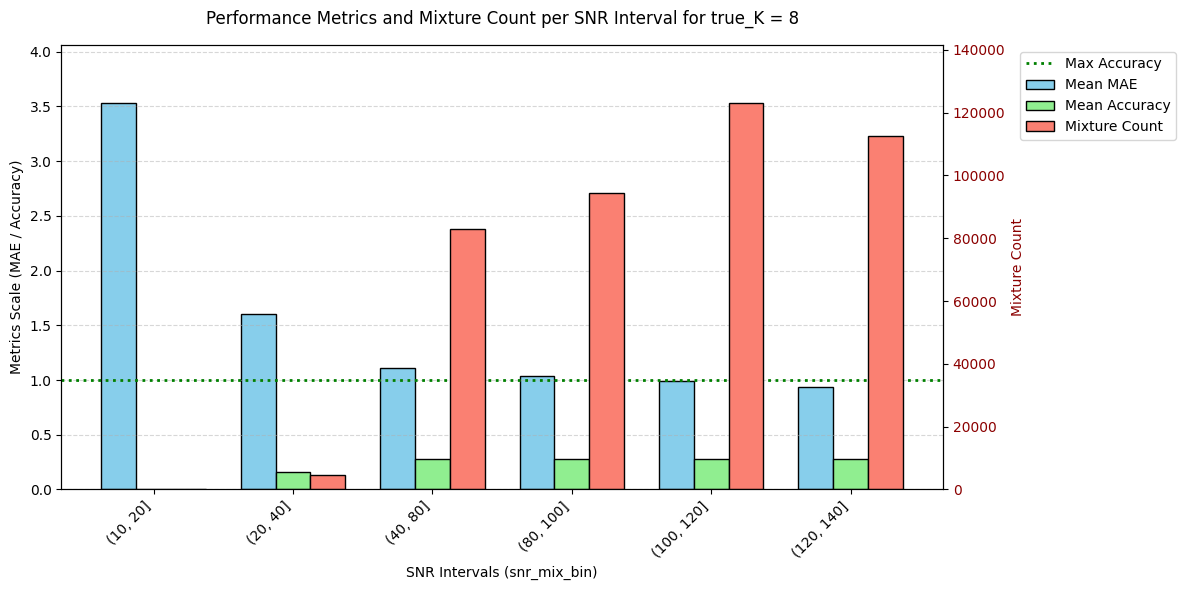

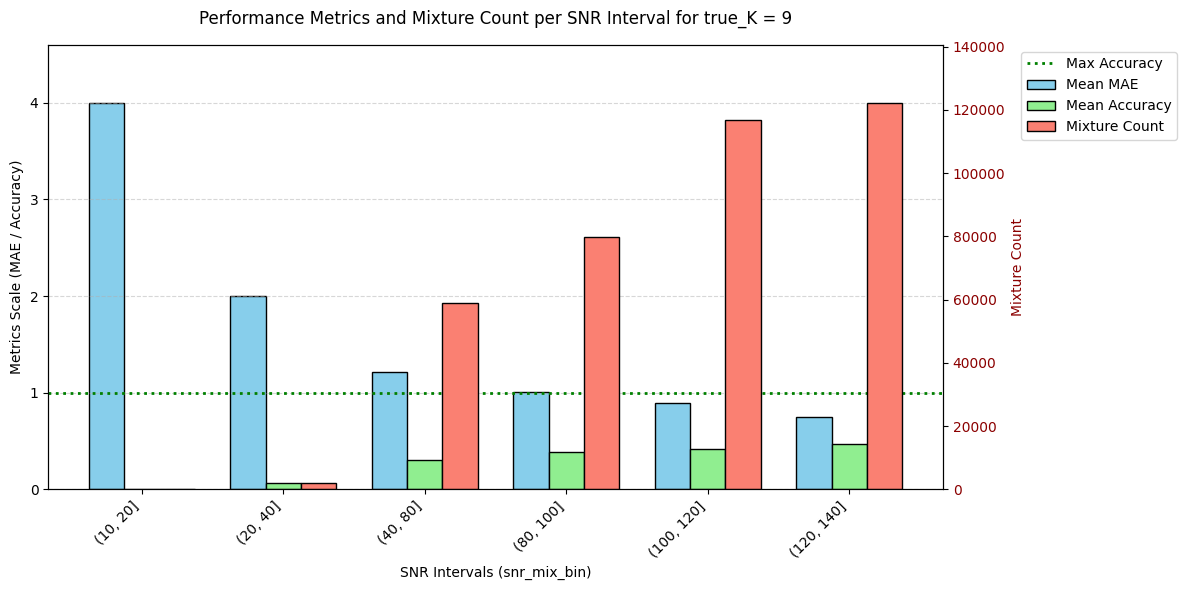

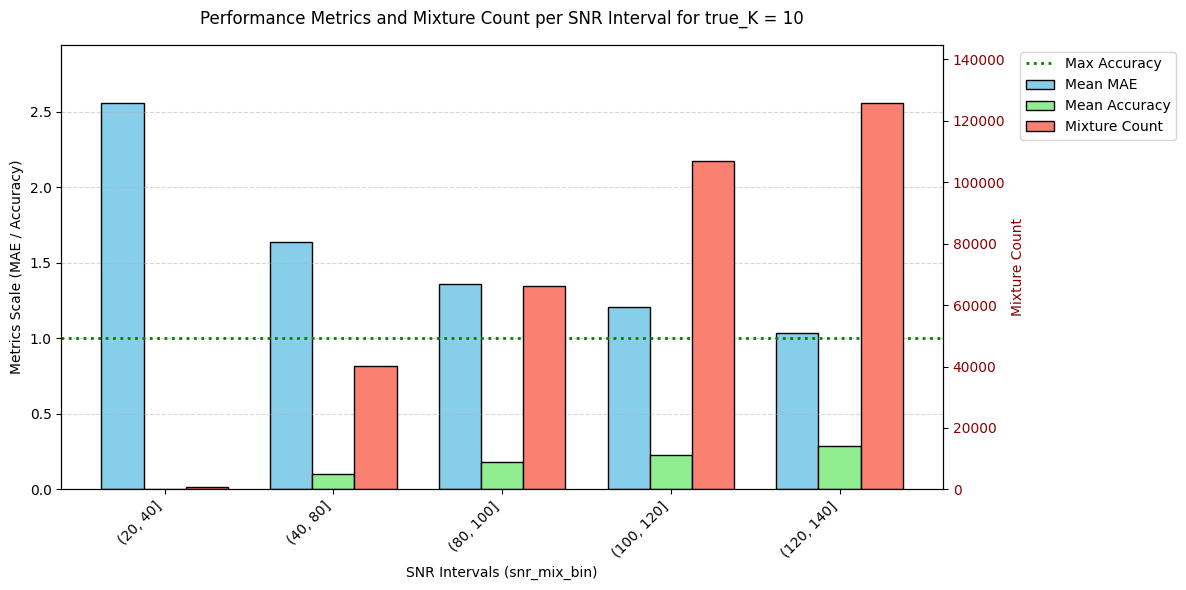

In [31]:
results_df["accuracy"] = (results_df["pred_K"] == results_df["true_K"]).astype(int)

snr_bins = [0, 5, 10, 20, 40, 80, 100, 120, 140]
results_df["snr_mix_bin"] = pd.cut(results_df["snr_mix"], bins=snr_bins)

grouped_df = (
    results_df.groupby(["true_K", "snr_mix_bin"], as_index=False)
    .agg(
        mean_mae=("mae", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mixture_count=("snr_mix", "count")
    )
)

unique_K = grouped_df["true_K"].unique()

for k_val in unique_K:
    sub_df = grouped_df[grouped_df["true_K"] == k_val].copy()
    sub_df["bin_str"] = sub_df["snr_mix_bin"].astype(str)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.axhline(y=1.0, color='green', linestyle=':', linewidth=2, label='Max Accuracy')
    x_indexes = np.arange(len(sub_df["bin_str"]))
    bar_width = 0.25

    rects1 = ax1.bar(
        x_indexes - bar_width,
        sub_df["mean_mae"],
        width=bar_width,
        color="skyblue",
        edgecolor="black",
        label="Mean MAE",
    )
    rects2 = ax1.bar(
        x_indexes,
        sub_df["mean_accuracy"],
        width=bar_width,
        color="lightgreen",
        edgecolor="black",
        label="Mean Accuracy",
    )
    
    ax1.set_xlabel("SNR Intervals (snr_mix_bin)")
    ax1.set_ylabel("Metrics Scale (MAE / Accuracy)", color="black")
    ax1.tick_params(axis="y", labelcolor="black")
    
    left_ymax = max(sub_df["mean_mae"].max(), sub_df["mean_accuracy"].max())
    ax1.set_ylim(0, max(1.0, left_ymax * 1.15))

    ax2 = ax1.twinx()
    rects3 = ax2.bar(
        x_indexes + bar_width,
        sub_df["mixture_count"],
        width=bar_width,
        color="salmon",
        edgecolor="black",
        label="Mixture Count",
    )
    ax2.set_ylabel("Mixture Count", color="darkred")
    ax2.tick_params(axis="y", labelcolor="darkred")
    
    right_ymax = sub_df["mixture_count"].max()
    ax2.set_ylim(0, right_ymax * 1.15)

    plt.title(f"Performance Metrics and Mixture Count per SNR Interval for true_K = {k_val}", pad=15)

    ax1.set_xticks(x_indexes)
    ax1.set_xticklabels(sub_df["bin_str"], rotation=45, ha="right")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    ax1.legend(
        lines1 + lines2, 
        labels1 + labels2, 
        loc="upper left", 
        bbox_to_anchor=(1.08, 1)
    )

    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [32]:
df = results_df.copy()

df["error_K"] = df["pred_K"] - df["true_K"]
df["abs_error_K"] = df["error_K"].abs()
df["accuracy"] = (df["pred_K"] == df["true_K"]).astype(float)

df["n_weak_5"] = df["true_K"] - df["n_visible_5"]
df["n_weak_10"] = df["true_K"] - df["n_visible_10"]
df["n_weak_20"] = df["true_K"] - df["n_visible_20"]

df["undercount"] = (df["error_K"] < 0).astype(float)
df["overcount"] = (df["error_K"] > 0).astype(float)

df["dominance_ratio"] = (df["max_snr"] ** 2) / (df["snr_mix"] ** 2)

summary = pd.Series({
    "n": len(df),
    "accuracy": df["accuracy"].mean(),
    "accuracy ±1": (df["abs_error_K"] <= 1).mean(),
    "accuracy ±2": (df["abs_error_K"] <= 2).mean(),
    "MAE": df["abs_error_K"].mean(),
    "mean error": df["error_K"].mean(),
})

display(summary)

n              5.242880e+06
accuracy       4.096668e-01
accuracy ±1    8.366936e-01
accuracy ±2    9.650253e-01
MAE            7.947491e-01
mean error    -1.131683e-01
dtype: float64

,accuracy,mae,mean_pred_K,mean_visible_5,mean_visible_10,mean_visible_20,count
true_K,,,,,,,
1,0.863824,0.140073,1.140073,0.942388,0.726791,0.511320,523471
2,0.526728,0.482566,2.078795,1.886726,1.455516,1.026253,524550
3,0.460183,0.608414,3.082912,2.830948,2.185083,1.540433,525619
4,0.375432,0.770845,4.096127,3.773053,2.913851,2.053749,524868
5,0.330224,0.915181,5.114487,4.716536,3.642185,2.565906,524363
6,0.285913,1.040002,6.113099,5.659454,4.369251,3.078230,523779
7,0.262723,1.082492,7.034274,6.603448,5.095970,3.591793,525351
8,0.268559,1.001652,7.820591,7.545439,5.823241,4.101976,523714
9,0.432682,0.839728,8.451844,8.490568,6.555350,4.620513,523754


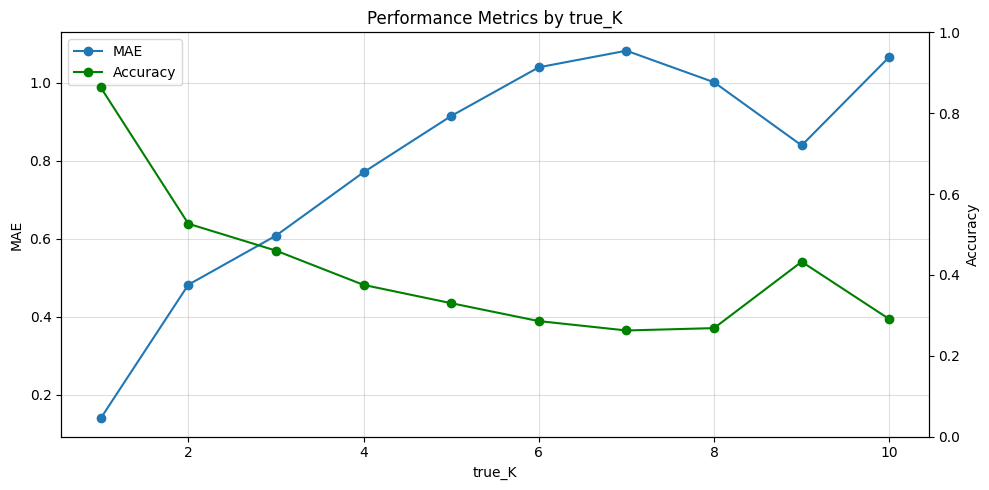

In [47]:
by_k = (
    df.groupby("true_K")
    .agg(
        accuracy=("accuracy", "mean"),
        mae=("abs_error_K", "mean"),
        mean_pred_K=("pred_K", "mean"),
        mean_visible_5=("n_visible_5", "mean"),
        mean_visible_10=("n_visible_10", "mean"),
        mean_visible_20=("n_visible_20", "mean"),
        count=("true_K", "count"),
    )
)

display(by_k)

fig, ax1 = plt.subplots(figsize=(10, 5))

x = by_k.index.to_numpy()

ax1.plot(x, by_k["mae"], marker="o", label="MAE")
ax1.set_xlabel("true_K")
ax1.set_ylabel("MAE")
ax1.grid(True, alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(x, by_k["accuracy"], marker="o", color="green", label="Accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Performance Metrics by true_K")
plt.tight_layout()
plt.show()

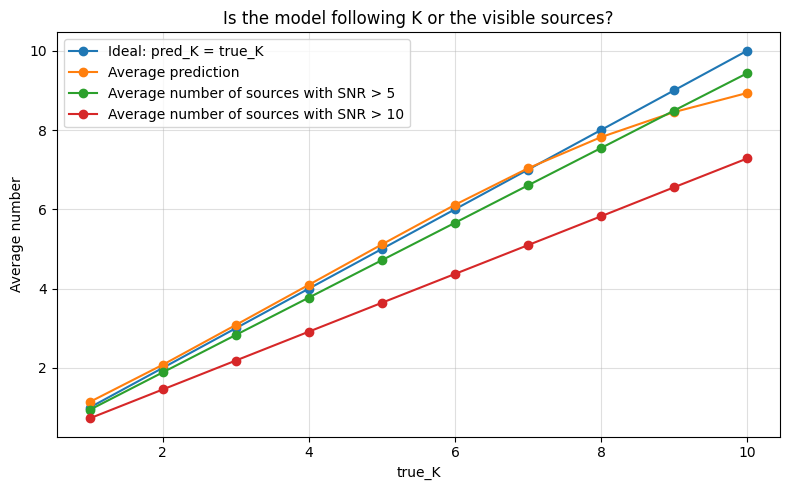

In [49]:
plt.figure(figsize=(8, 5))

x = by_k.index.to_numpy()

plt.plot(x, x, marker="o", label="Ideal: pred_K = true_K")
plt.plot(x, by_k["mean_pred_K"], marker="o", label="Average prediction")
plt.plot(x, by_k["mean_visible_5"], marker="o", label="Average number of sources with SNR > 5")
plt.plot(x, by_k["mean_visible_10"], marker="o", label="Average number of sources with SNR > 10")

plt.xlabel("true_K")
plt.ylabel("Average number")
plt.title("Is the model following K or the visible sources?")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

,count,accuracy,mae,mean_error,undercount_rate,overcount_rate
n_weak_5,,,,,,
0,3856635,0.447539,0.710619,0.121163,0.227899,0.324561
1,1164257,0.331764,0.934360,-0.633560,0.539627,0.128609
2,197021,0.172956,1.443750,-1.367270,0.790987,0.036057
3,22981,0.064270,2.100431,-2.087812,0.929550,0.006179
4,1872,0.014957,2.786859,-2.786859,0.985043,0.000000
5,110,0.000000,3.554545,-3.554545,1.000000,0.000000
6,3,0.000000,3.000000,-3.000000,1.000000,0.000000
7,1,0.000000,6.000000,-6.000000,1.000000,0.000000


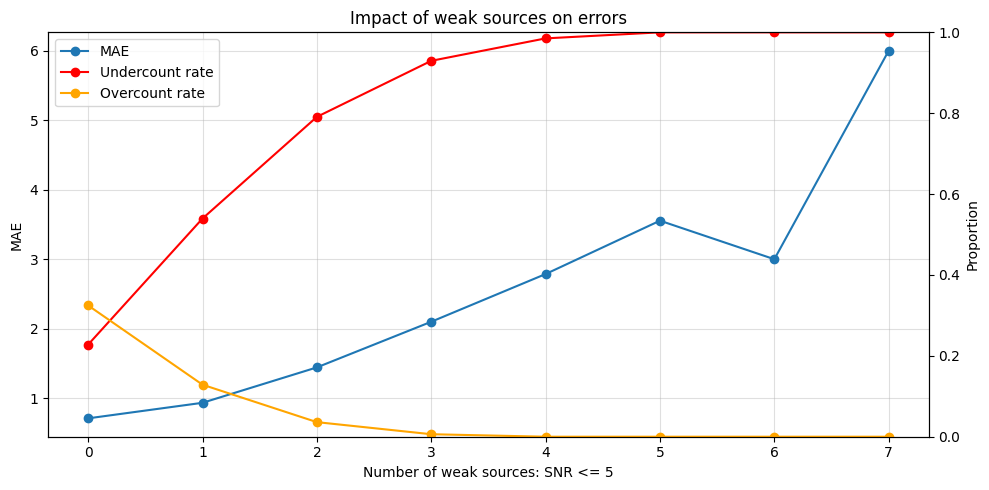

In [38]:
weak_stats = (
    df.groupby("n_weak_5")
    .agg(
        count=("true_K", "count"),
        accuracy=("accuracy", "mean"),
        mae=("abs_error_K", "mean"),
        mean_error=("error_K", "mean"),
        undercount_rate=("undercount", "mean"),
        overcount_rate=("overcount", "mean"),
    )
)

display(weak_stats)

fig, ax1 = plt.subplots(figsize=(10, 5))

x = weak_stats.index.to_numpy()

ax1.plot(x, weak_stats["mae"], marker="o", label="MAE")
ax1.set_xlabel("Number of weak sources: SNR <= 5")
ax1.set_ylabel("MAE")
ax1.grid(True, alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(x, weak_stats["undercount_rate"], marker="o", color="red", label="Undercount rate")
ax2.plot(x, weak_stats["overcount_rate"], marker="o", color="orange", label="Overcount rate")
ax2.set_ylabel("Proportion")
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Impact of weak sources on errors")
plt.tight_layout()
plt.show()

In [40]:
weak_counts = (
    df["n_weak_5"]
    .value_counts()
    .sort_index()
    .rename_axis("n_weak_5")
    .reset_index(name="count")
)

weak_counts["proportion"] = weak_counts["count"] / weak_counts["count"].sum()

display(weak_counts)

# fig, ax1 = plt.subplots(figsize=(9, 5))

# x = weak_counts["n_weak_5"].to_numpy()

# ax1.bar(
#     x,
#     weak_counts["count"],
#     color="skyblue",
#     edgecolor="black",
#     label="Nombre de mixtures",
# )

# ax1.set_xlabel("Nombre de sources faibles : SNR <= 5")
# ax1.set_ylabel("Nombre de mixtures")
# ax1.grid(axis="y", alpha=0.4)

# ax2 = ax1.twinx()
# ax2.plot(
#     x,
#     weak_counts["proportion"],
#     marker="o",
#     color="darkred",
#     label="Proportion",
# )

# ax2.set_ylabel("Proportion")
# ax2.set_ylim(0, max(weak_counts["proportion"]) * 1.15)

# for xi, prop in zip(x, weak_counts["proportion"]):
#     ax2.text(
#         xi,
#         prop,
#         f"{prop:.1%}",
#         ha="center",
#         va="bottom",
#         fontsize=9,
#         color="darkred",
#     )

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.title("Fréquence du nombre de sources faibles dans les mixtures")
# plt.tight_layout()
# plt.show()

,n_weak_5,count,proportion
0,0,3856635,7.355947e-01
1,1,1164257,2.220644e-01
2,2,197021,3.757877e-02
3,3,22981,4.383278e-03
4,4,1872,3.570557e-04
5,5,110,2.098083e-05
6,6,3,5.722046e-07
7,7,1,1.907349e-07


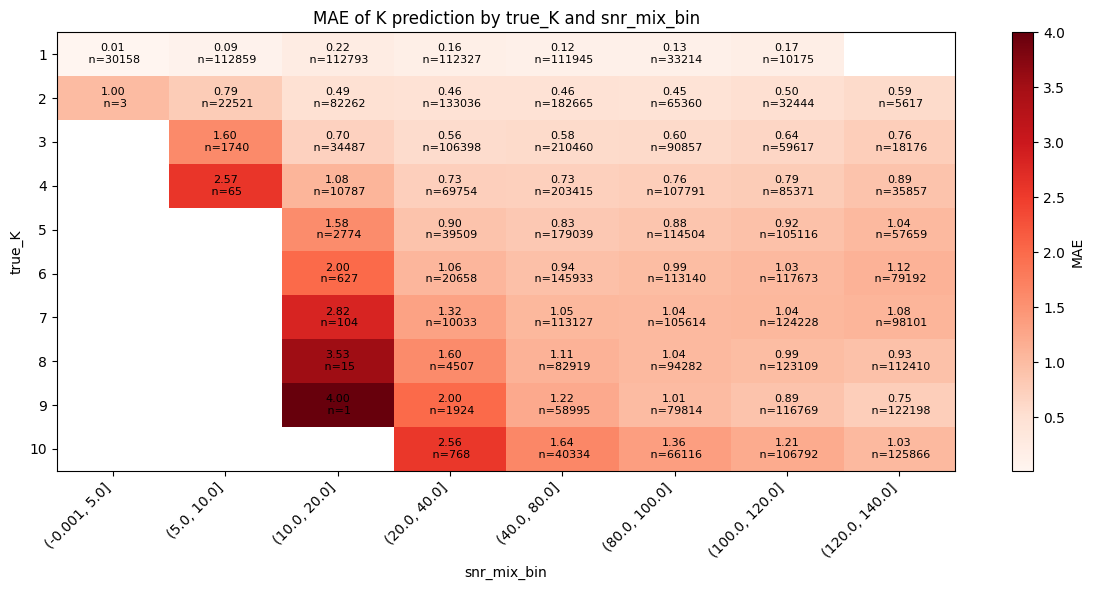

In [50]:
snr_bins = [0, 5, 10, 20, 40, 80, 100, 120, 140]
df["snr_mix_bin"] = pd.cut(df["snr_mix"], bins=snr_bins, include_lowest=True)

heat_mae = df.pivot_table(
    index="true_K",
    columns="snr_mix_bin",
    values="abs_error_K",
    aggfunc="mean",
    observed=False,
)

heat_count = df.pivot_table(
    index="true_K",
    columns="snr_mix_bin",
    values="abs_error_K",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(heat_mae, cmap="Reds", aspect="auto")

ax.set_title("MAE of K prediction by true_K and snr_mix_bin")
ax.set_xlabel("snr_mix_bin")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(heat_mae.columns)))
ax.set_yticks(np.arange(len(heat_mae.index)))
ax.set_xticklabels([str(c) for c in heat_mae.columns], rotation=45, ha="right")
ax.set_yticklabels(heat_mae.index)

for i in range(heat_mae.shape[0]):
    for j in range(heat_mae.shape[1]):
        val = heat_mae.iloc[i, j]
        count = heat_count.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}\n n={int(count)}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="MAE")
plt.tight_layout()
plt.show()

Jusque ici : 
- On a plus le raccourci par l'energie 
- Les sources faibles (SNR < 5) expliquent une partie des erreurs mais pas toutes
- Le modèle apprend bien à compter le nombres de sources total car pred_K suit bien globalement true_K

- Quand K grandit ça marche moins bien c'est logique, cependant maintenant on veut voir dans quel cas il va réussir et dans quel cas non 

In [51]:
df = results_df.copy()

df["correct"] = (df["pred_K"] == df["true_K"])
df["accuracy"] = df["correct"].astype(float)

df["error_K"] = df["pred_K"] - df["true_K"]
df["abs_error_K"] = df["error_K"].abs()

df["undercount"] = df["error_K"] < 0
df["overcount"] = df["error_K"] > 0

df["n_weak_5"] = df["true_K"] - df["n_visible_5"]
df["n_weak_10"] = df["true_K"] - df["n_visible_10"]
df["n_weak_20"] = df["true_K"] - df["n_visible_20"]

df["dominance_ratio"] = (df["max_snr"] ** 2) / (df["snr_mix"] ** 2)

df["visible_fraction_5"] = df["n_visible_5"] / df["true_K"]
df["visible_fraction_10"] = df["n_visible_10"] / df["true_K"]
df["visible_fraction_20"] = df["n_visible_20"] / df["true_K"]

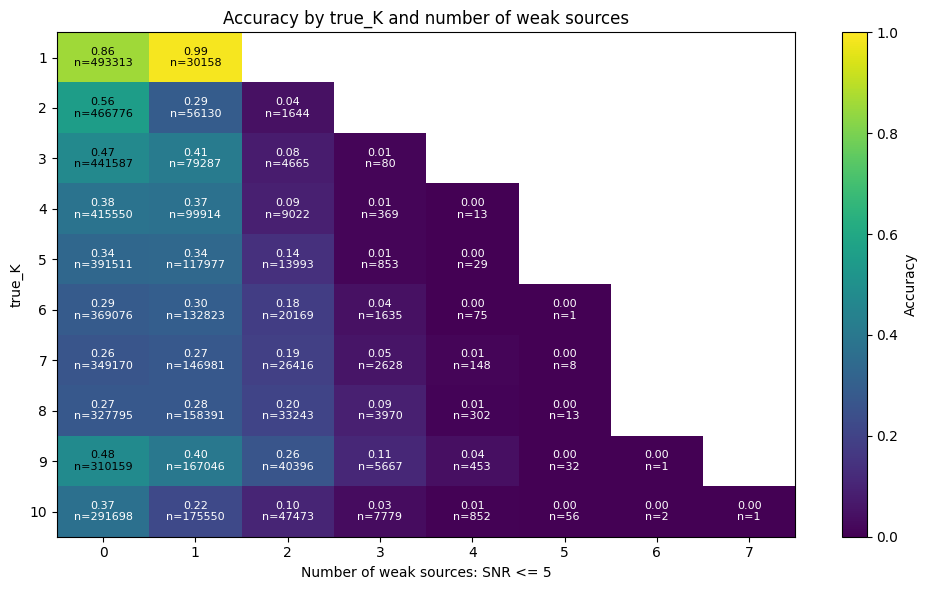

In [69]:
pivot_acc = df.pivot_table(
    index="true_K",
    columns="n_weak_5",
    values="accuracy",
    aggfunc="mean",
    observed=False,
)

pivot_count = df.pivot_table(
    index="true_K",
    columns="n_weak_5",
    values="accuracy",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(pivot_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")

ax.set_title("Accuracy by true_K and number of weak sources")
ax.set_xlabel("Number of weak sources: SNR <= 5")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_acc.columns)))
ax.set_yticks(np.arange(len(pivot_acc.index)))
ax.set_xticklabels(pivot_acc.columns)
ax.set_yticklabels(pivot_acc.index)

for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        acc = pivot_acc.iloc[i, j]
        count = pivot_count.iloc[i, j]
        if not np.isnan(acc):
            ax.text(
                j, i,
                f"{acc:.2f}\nn={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if acc < 0.45 else "black",
            )

fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

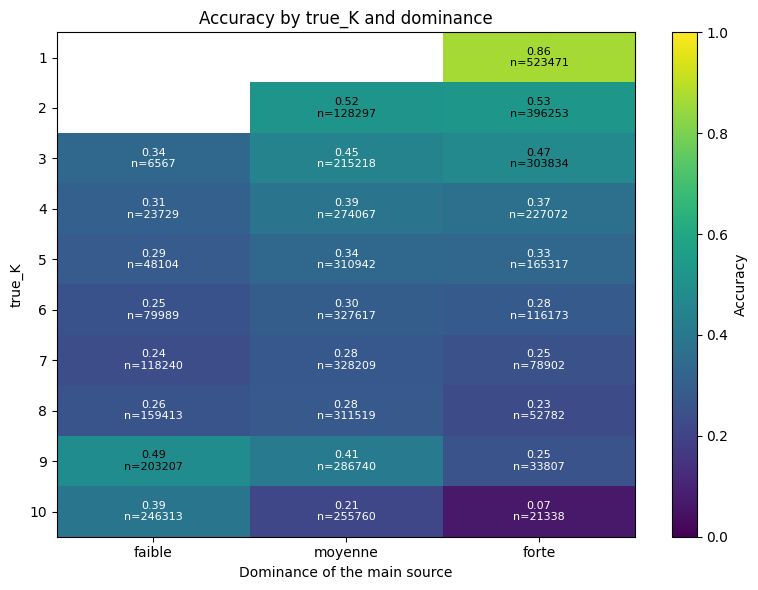

In [70]:
df["dominance_bin"] = pd.cut(
    df["dominance_ratio"],
    bins=[0.0, 0.4, 0.7, 1.0],
    labels=["faible", "moyenne", "forte"],
    include_lowest=True,
)

pivot_acc = df.pivot_table(
    index="true_K",
    columns="dominance_bin",
    values="accuracy",
    aggfunc="mean",
    observed=False,
)

pivot_count = df.pivot_table(
    index="true_K",
    columns="dominance_bin",
    values="accuracy",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(pivot_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")

ax.set_title("Accuracy by true_K and dominance")
ax.set_xlabel("Dominance of the main source")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_acc.columns)))
ax.set_yticks(np.arange(len(pivot_acc.index)))
ax.set_xticklabels(pivot_acc.columns)
ax.set_yticklabels(pivot_acc.index)

for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        acc = pivot_acc.iloc[i, j]
        count = pivot_count.iloc[i, j]
        if not np.isnan(acc):
            ax.text(
                j, i,
                f"{acc:.2f}\nn={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if acc < 0.45 else "black",
            )

fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

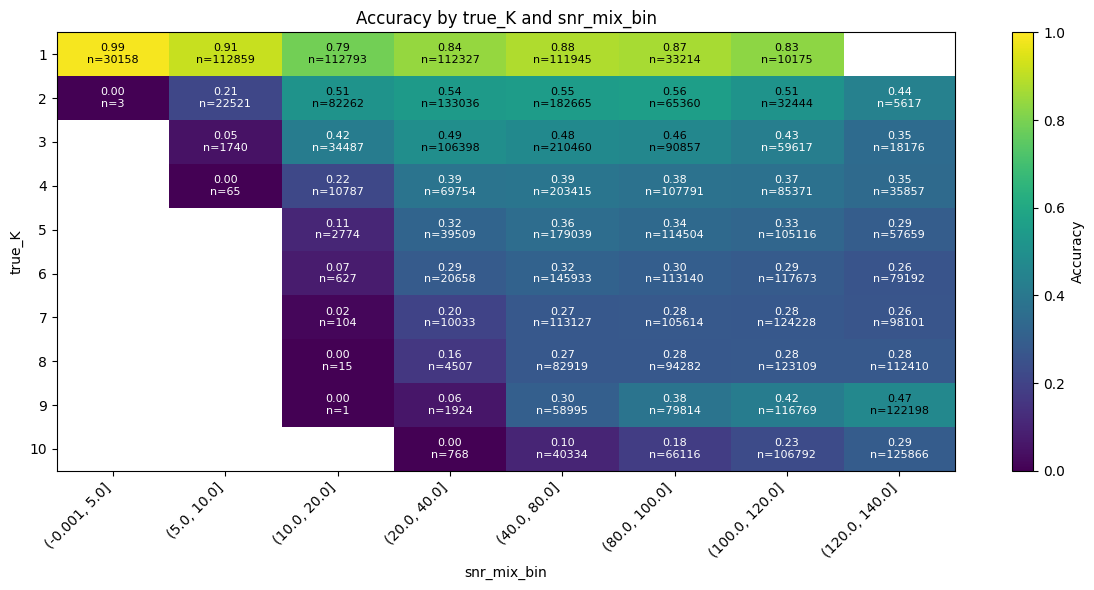

In [71]:
snr_bins = [0, 5, 10, 20, 40, 80, 100, 120, 140]
df["snr_mix_bin"] = pd.cut(df["snr_mix"], bins=snr_bins, include_lowest=True)

pivot_acc = df.pivot_table(
    index="true_K",
    columns="snr_mix_bin",
    values="accuracy",
    aggfunc="mean",
    observed=False,
)

pivot_count = df.pivot_table(
    index="true_K",
    columns="snr_mix_bin",
    values="accuracy",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(pivot_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")

ax.set_title("Accuracy by true_K and snr_mix_bin")
ax.set_xlabel("snr_mix_bin")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_acc.columns)))
ax.set_yticks(np.arange(len(pivot_acc.index)))
ax.set_xticklabels([str(c) for c in pivot_acc.columns], rotation=45, ha="right")
ax.set_yticklabels(pivot_acc.index)

for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        acc = pivot_acc.iloc[i, j]
        count = pivot_count.iloc[i, j]
        if not np.isnan(acc):
            ax.text(
                j, i,
                f"{acc:.2f}\nn={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if acc < 0.45 else "black",
            )

fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

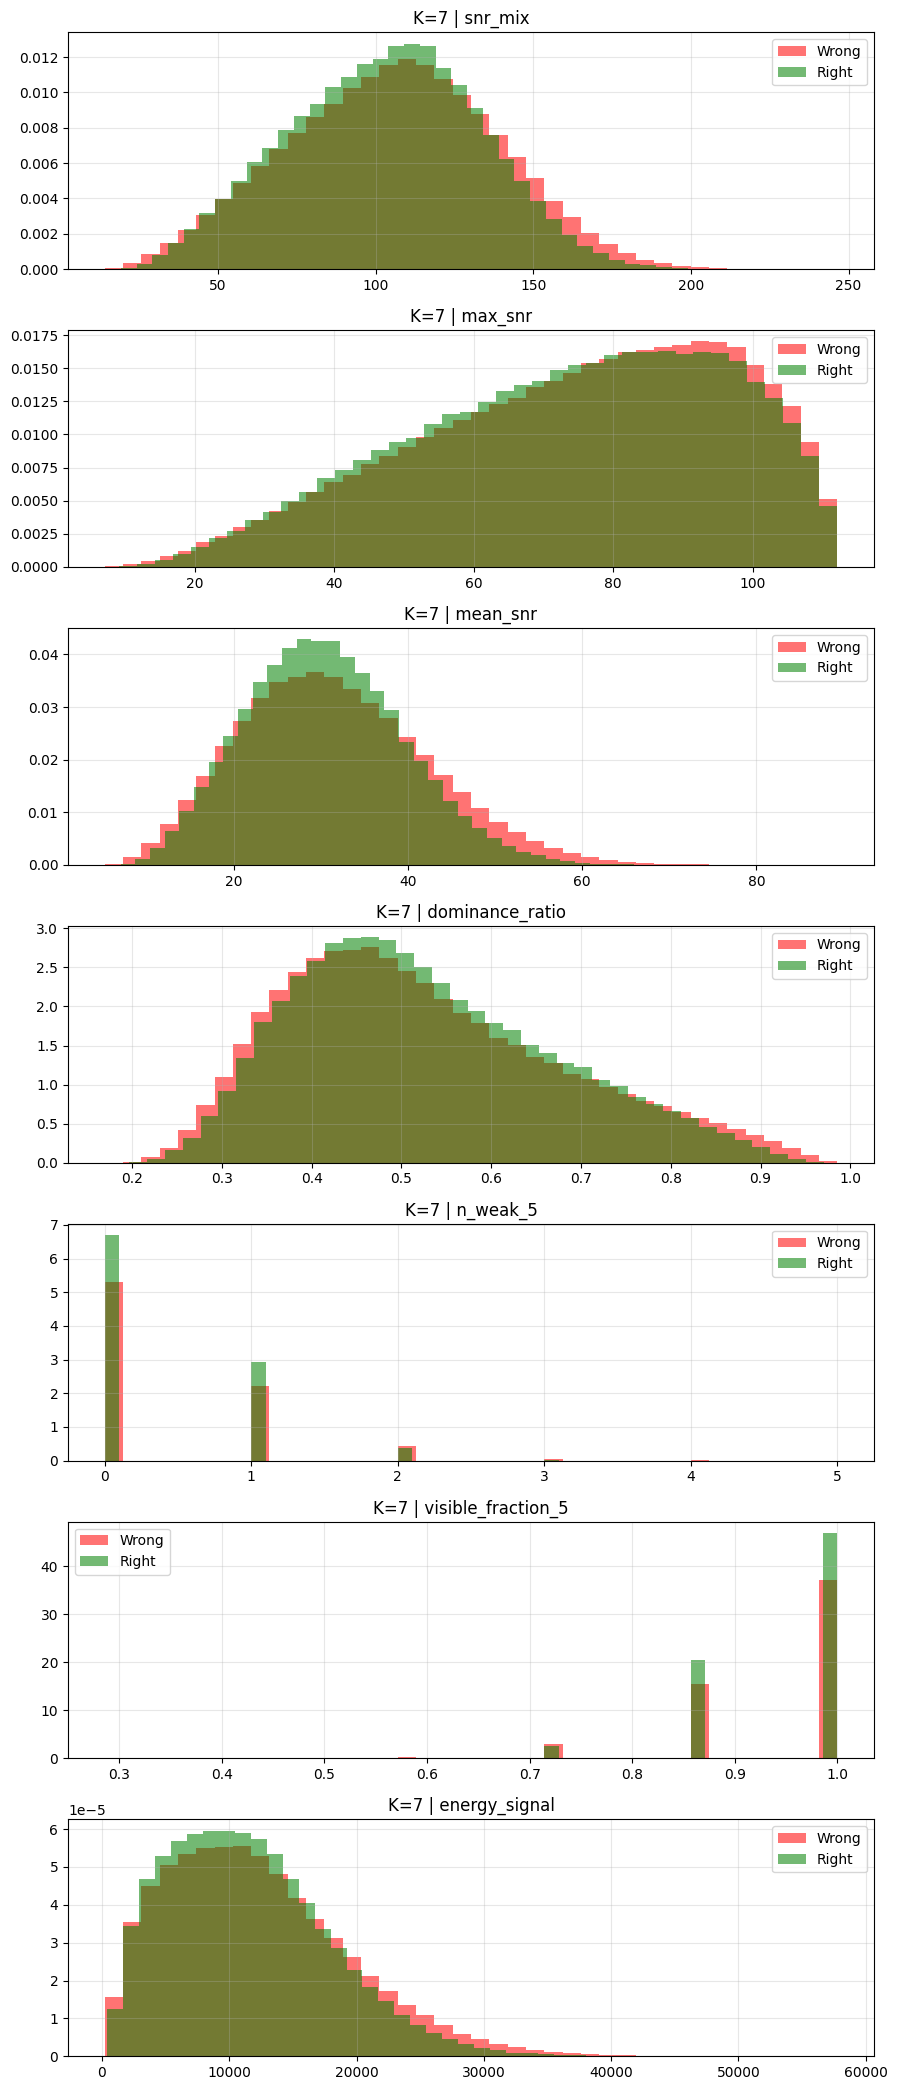

In [72]:
K_TO_INSPECT = 7

sub = df[df["true_K"] == K_TO_INSPECT].copy()

features = [
    "snr_mix",
    "max_snr",
    "mean_snr",
    "dominance_ratio",
    "n_weak_5",
    "visible_fraction_5",
    "energy_signal",
]

fig, axes = plt.subplots(len(features), 1, figsize=(9, 3 * len(features)))

for ax, feature in zip(axes, features):
    correct_values = sub[sub["correct"]][feature].dropna()
    wrong_values = sub[~sub["correct"]][feature].dropna()

    ax.hist(
        wrong_values,
        bins=40,
        alpha=0.55,
        density=True,
        label="Wrong",
        color="red",
    )
    ax.hist(
        correct_values,
        bins=40,
        alpha=0.55,
        density=True,
        label="Right",
        color="green",
    )

    ax.set_title(f"K={K_TO_INSPECT} | {feature}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

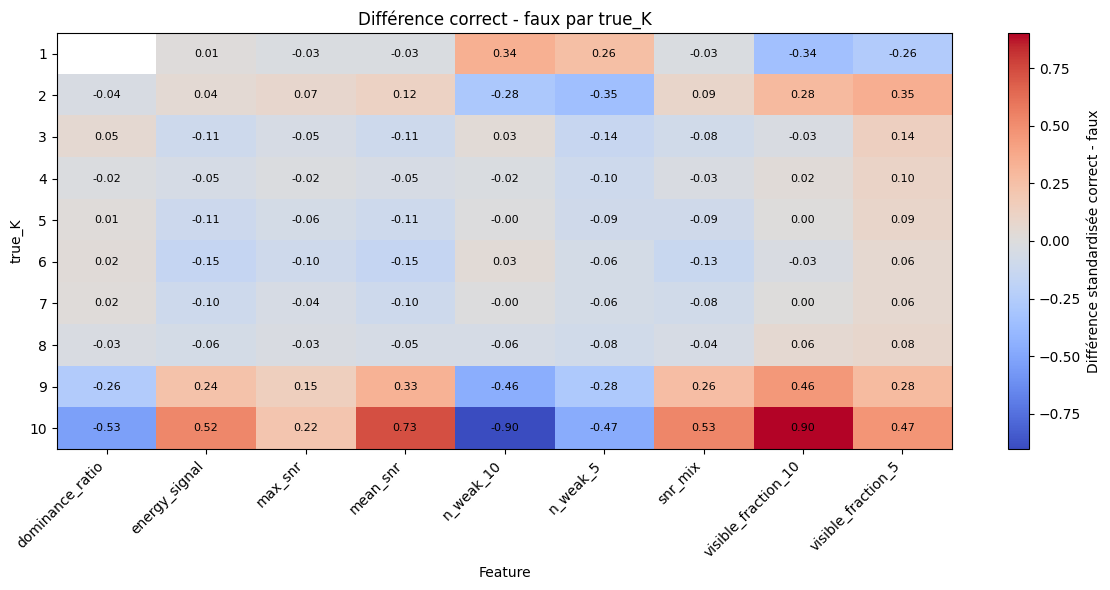

In [67]:
features = [
    "snr_mix",
    "max_snr",
    "mean_snr",
    "dominance_ratio",
    "n_weak_5",
    "n_weak_10",
    "visible_fraction_5",
    "visible_fraction_10",
    "energy_signal",
]

rows = []

for k, sub in df.groupby("true_K"):
    correct = sub[sub["correct"]]
    wrong = sub[~sub["correct"]]

    for feature in features:
        if len(correct) == 0 or len(wrong) == 0:
            continue

        std = sub[feature].std()
        if std == 0 or np.isnan(std):
            continue

        diff = (correct[feature].mean() - wrong[feature].mean()) / std

        rows.append({
            "true_K": k,
            "feature": feature,
            "standardized_diff_correct_minus_wrong": diff,
        })

diff_df = pd.DataFrame(rows)

pivot_diff = diff_df.pivot(
    index="true_K",
    columns="feature",
    values="standardized_diff_correct_minus_wrong",
)

fig, ax = plt.subplots(figsize=(12, 6))

vmax = np.nanmax(np.abs(pivot_diff.to_numpy()))
im = ax.imshow(pivot_diff, cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_title("Différence correct - faux par true_K")
ax.set_xlabel("Feature")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_diff.columns)))
ax.set_yticks(np.arange(len(pivot_diff.index)))
ax.set_xticklabels(pivot_diff.columns, rotation=45, ha="right")
ax.set_yticklabels(pivot_diff.index)

for i in range(pivot_diff.shape[0]):
    for j in range(pivot_diff.shape[1]):
        val = pivot_diff.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Différence standardisée correct - faux")
plt.tight_layout()
plt.show()

- n_weak_5 va avoir tendance à degrader les performances. 
- quand K est grand et que et qu'il y'a une dominance forte les performances vont chuter
- plus haut snr_mix augmente en corrélation avec K, mieux le modèle performe. mais ça reste toujours très moyen < 40% d'acc


In [74]:
def upper_triangle_values(matrix):
    k = matrix.shape[0]
    return matrix[np.triu_indices(k, k=1)]


def build_norm_stats(ds):
    log_amp = np.log10(np.asarray(ds.amp))
    f0 = np.asarray(ds.f0)
    fdot = np.asarray(ds.fdot)
    sin_beta = np.sin(np.asarray(ds.beta))

    return {
        "log_amp_min": log_amp.min(),
        "log_amp_max": log_amp.max(),
        "f0_min": f0.min(),
        "f0_max": f0.max(),
        "fdot_min": fdot.min(),
        "fdot_max": fdot.max(),
        "sin_beta_min": sin_beta.min(),
        "sin_beta_max": sin_beta.max(),
    }


def normalize(x, xmin, xmax):
    return (x - xmin) / (xmax - xmin + 1e-12)


def compute_mixture_separation(ds, mixture_idx, norm_stats, compute_wave_corr=True):
    source_indices, true_k = ds.fixed_mixtures[int(mixture_idx)]
    source_indices = np.asarray(source_indices)

    if true_k < 2:
        return {
            "min_delta_f0_hz": np.nan,
            "min_delta_f0_norm": np.nan,
            "min_pairwise_param_dist": np.nan,
            "mean_pairwise_param_dist": np.nan,
            "max_waveform_corr": np.nan,
            "mean_waveform_corr": np.nan,
            "n_pairs": 0,
        }

    amp = np.asarray(ds.amp[source_indices])
    f0 = np.asarray(ds.f0[source_indices])
    fdot = np.asarray(ds.fdot[source_indices])
    lam = np.asarray(ds.lam[source_indices])
    beta = np.asarray(ds.beta[source_indices])

    log_amp = np.log10(amp)
    sin_beta = np.sin(beta)

    log_amp_n = normalize(log_amp, norm_stats["log_amp_min"], norm_stats["log_amp_max"])
    f0_n = normalize(f0, norm_stats["f0_min"], norm_stats["f0_max"])
    fdot_n = normalize(fdot, norm_stats["fdot_min"], norm_stats["fdot_max"])
    sin_beta_n = normalize(sin_beta, norm_stats["sin_beta_min"], norm_stats["sin_beta_max"])

    d_f0_hz = np.abs(f0[:, None] - f0[None, :])
    d_f0_norm = np.abs(f0_n[:, None] - f0_n[None, :])

    d_log_amp = np.abs(log_amp_n[:, None] - log_amp_n[None, :])
    d_fdot = np.abs(fdot_n[:, None] - fdot_n[None, :])
    d_sin_beta = np.abs(sin_beta_n[:, None] - sin_beta_n[None, :])

    d_lam = np.abs(lam[:, None] - lam[None, :])
    d_lam = np.minimum(d_lam, 2 * np.pi - d_lam) / np.pi

    d_param = np.sqrt(
        d_log_amp ** 2
        + d_f0_norm ** 2
        + d_fdot ** 2
        + d_sin_beta ** 2
        + d_lam ** 2
    )

    pair_d_f0_hz = upper_triangle_values(d_f0_hz)
    pair_d_f0_norm = upper_triangle_values(d_f0_norm)
    pair_d_param = upper_triangle_values(d_param)

    result = {
        "min_delta_f0_hz": pair_d_f0_hz.min(),
        "min_delta_f0_norm": pair_d_f0_norm.min(),
        "min_pairwise_param_dist": pair_d_param.min(),
        "mean_pairwise_param_dist": pair_d_param.mean(),
        "n_pairs": len(pair_d_param),
    }

    if compute_wave_corr:
        waves = np.asarray(ds.waveforms[source_indices], dtype=np.float32)
        waves = waves.reshape(true_k, -1)

        norms = np.linalg.norm(waves, axis=1, keepdims=True) + 1e-12
        waves_n = waves / norms

        corr = np.abs(waves_n @ waves_n.T)
        pair_corr = upper_triangle_values(corr)

        result["max_waveform_corr"] = pair_corr.max()
        result["mean_waveform_corr"] = pair_corr.mean()
    else:
        result["max_waveform_corr"] = np.nan
        result["mean_waveform_corr"] = np.nan

    return result

In [ ]:
df = results_df.copy()

df["correct"] = df["pred_K"] == df["true_K"]
df["accuracy"] = df["correct"].astype(float)
df["error_K"] = df["pred_K"] - df["true_K"]
df["abs_error_K"] = df["error_K"].abs()

DIAG_PER_K = 5000

parts = []

for k, sub in df[df["true_K"] >= 2].groupby("true_K"):
    n = min(len(sub), DIAG_PER_K)
    parts.append(sub.sample(n=n, random_state=0))

diag_base = pd.concat(parts, ignore_index=True)

norm_stats = build_norm_stats(base_ds)

diag_rows = []

for run, run_df in tqdm(diag_base.groupby("run"), desc="Runs"):
    seed = seeds[int(run)]
    ds = make_dataset_view(base_ds, seed=seed, noise=False)

    for _, row in tqdm(run_df.iterrows(), total=len(run_df), leave=False):
        stats = compute_mixture_separation(
            ds,
            mixture_idx=int(row["idx"]),
            norm_stats=norm_stats,
            compute_wave_corr=True,
        )

        stats["run"] = int(row["run"])
        stats["idx"] = int(row["idx"])

        diag_rows.append(stats)

diag_features = pd.DataFrame(diag_rows)

df_diag = diag_base.merge(
    diag_features,
    on=["run", "idx"],
    how="left",
)

print(df_diag.columns.tolist())
display(df_diag.head())

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4699 [00:00<?, ?it/s]

  0%|          | 0/4383 [00:00<?, ?it/s]

  0%|          | 0/4455 [00:00<?, ?it/s]

  0%|          | 0/4479 [00:00<?, ?it/s]

...

  0%|          | 0/4511 [00:00<?, ?it/s]

  0%|          | 0/4332 [00:00<?, ?it/s]

  0%|          | 0/4401 [00:00<?, ?it/s]

  0%|          | 0/4571 [00:00<?, ?it/s]

,run,seed,idx,pred_K,pred_score,correct,error_K,abs_error_K,loss,snr_values,...,snr_mix_bin,mae,accuracy,min_delta_f0_hz,min_delta_f0_norm,min_pairwise_param_dist,mean_pairwise_param_dist,n_pairs,max_waveform_corr,mean_waveform_corr
0,3,1234,394534,3,3.128601,False,1,1,0.179055,"[106.42632293701172, 41.02927017211914]",...,"(100, 120]",1,0.0,6.840564e-07,0.168657,0.376417,0.376417,1,0.001464,0.001464
1,7,151617,338908,2,2.559509,True,0,0,0.080641,"[17.83768081665039, 13.129586219787598]",...,"(20, 40]",0,1.0,2.279878e-06,0.562112,0.594896,0.594896,1,0.006309,0.006309
2,9,212223,181470,1,1.701327,False,-1,1,0.111158,"[53.93022155761719, 5.693743705749512]",...,"(40, 80]",1,0.0,1.272652e-06,0.313777,1.217198,1.217198,1,0.002201,0.002201
3,9,212223,415499,2,2.540504,True,0,0,0.074537,"[15.972281455993652, 48.028629302978516]",...,"(40, 80]",0,1.0,2.598390e-07,0.064064,1.092230,1.092230,1,0.004073,0.004073
4,4,5678,316123,2,2.051340,True,0,0,0.050577,"[7.308773994445801, 13.640626907348633]",...,"(10, 20]",0,1.0,2.603047e-07,0.064179,0.922070,0.922070,1,0.063669,0.063669


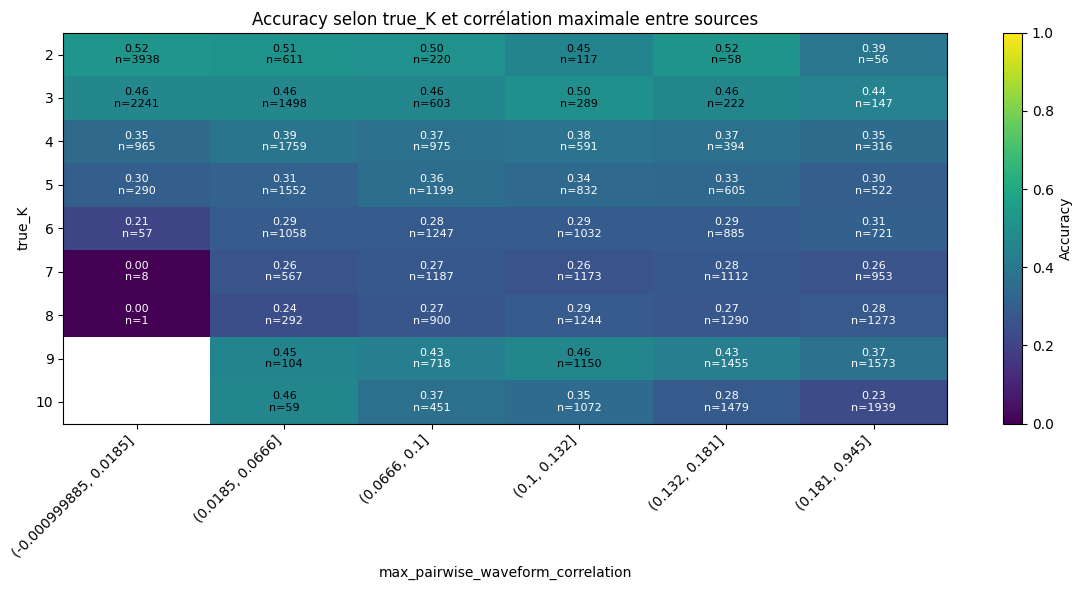

In [78]:
df_diag["wave_corr_bin"] = pd.qcut(
    df_diag["max_waveform_corr"],
    q=6,
    duplicates="drop",
)

pivot_acc = df_diag.pivot_table(
    index="true_K",
    columns="wave_corr_bin",
    values="accuracy",
    aggfunc="mean",
    observed=False,
)

pivot_count = df_diag.pivot_table(
    index="true_K",
    columns="wave_corr_bin",
    values="accuracy",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(pivot_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")

ax.set_title("Accuracy selon true_K et corrélation maximale entre sources")
ax.set_xlabel("max_pairwise_waveform_correlation")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_acc.columns)))
ax.set_yticks(np.arange(len(pivot_acc.index)))
ax.set_xticklabels([str(c) for c in pivot_acc.columns], rotation=45, ha="right")
ax.set_yticklabels(pivot_acc.index)

for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        acc = pivot_acc.iloc[i, j]
        count = pivot_count.iloc[i, j]

        if not np.isnan(acc):
            ax.text(
                j,
                i,
                f"{acc:.2f}\nn={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if acc < 0.45 else "black",
            )

fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

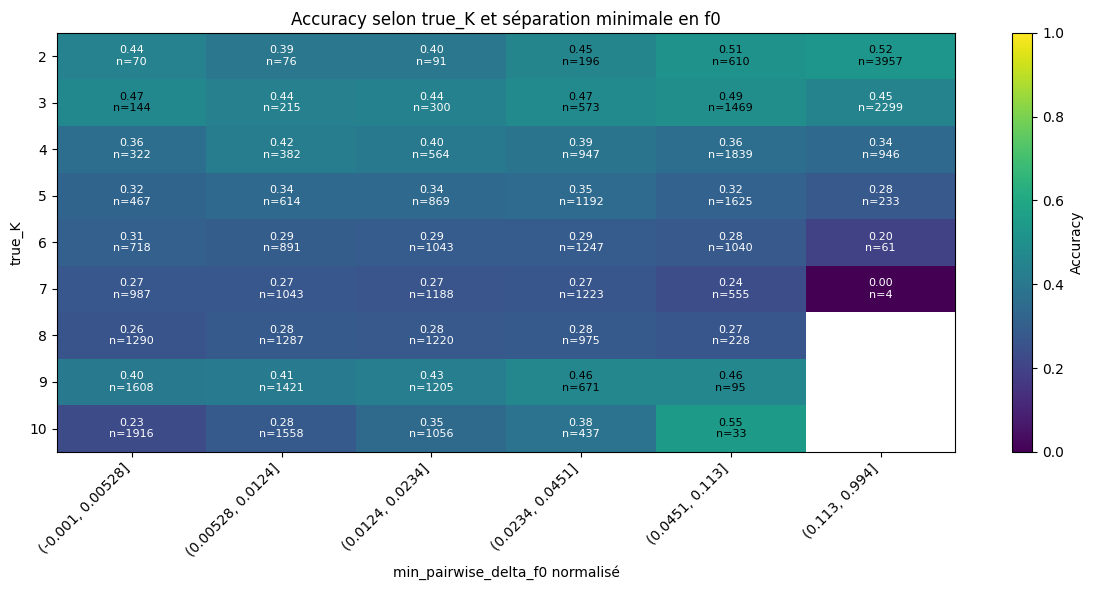

In [79]:
df_diag["min_delta_f0_bin"] = pd.qcut(
    df_diag["min_delta_f0_norm"],
    q=6,
    duplicates="drop",
)

pivot_acc = df_diag.pivot_table(
    index="true_K",
    columns="min_delta_f0_bin",
    values="accuracy",
    aggfunc="mean",
    observed=False,
)

pivot_count = df_diag.pivot_table(
    index="true_K",
    columns="min_delta_f0_bin",
    values="accuracy",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(pivot_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")

ax.set_title("Accuracy selon true_K et séparation minimale en f0")
ax.set_xlabel("min_pairwise_delta_f0 normalisé")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_acc.columns)))
ax.set_yticks(np.arange(len(pivot_acc.index)))
ax.set_xticklabels([str(c) for c in pivot_acc.columns], rotation=45, ha="right")
ax.set_yticklabels(pivot_acc.index)

for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        acc = pivot_acc.iloc[i, j]
        count = pivot_count.iloc[i, j]

        if not np.isnan(acc):
            ax.text(
                j,
                i,
                f"{acc:.2f}\nn={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if acc < 0.45 else "black",
            )

fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

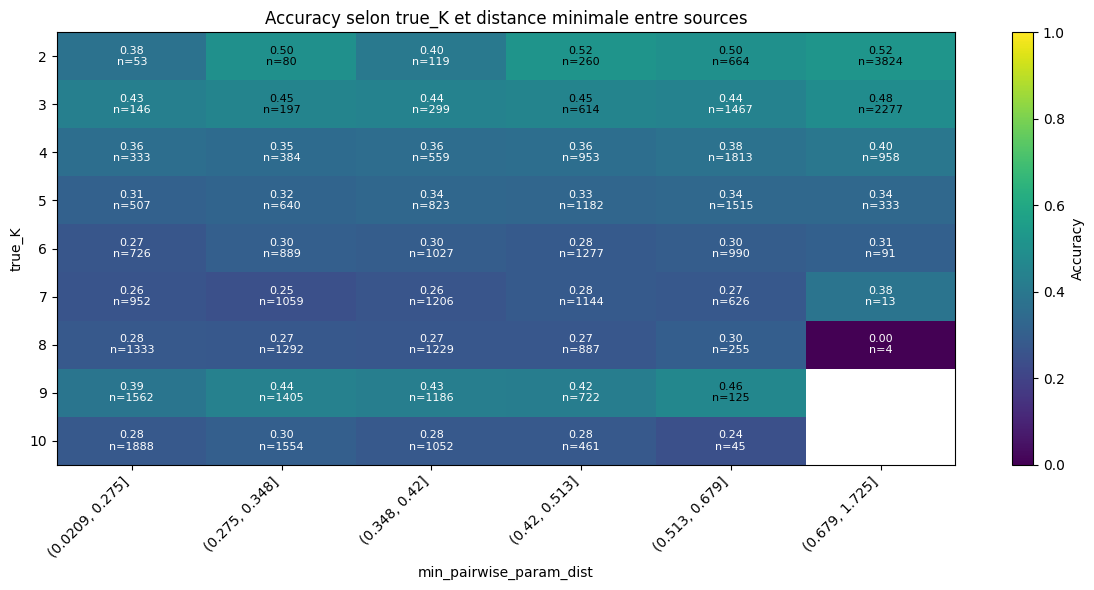

In [80]:
df_diag["min_param_dist_bin"] = pd.qcut(
    df_diag["min_pairwise_param_dist"],
    q=6,
    duplicates="drop",
)

pivot_acc = df_diag.pivot_table(
    index="true_K",
    columns="min_param_dist_bin",
    values="accuracy",
    aggfunc="mean",
    observed=False,
)

pivot_count = df_diag.pivot_table(
    index="true_K",
    columns="min_param_dist_bin",
    values="accuracy",
    aggfunc="count",
    observed=False,
)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(pivot_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")

ax.set_title("Accuracy selon true_K et distance minimale entre sources")
ax.set_xlabel("min_pairwise_param_dist")
ax.set_ylabel("true_K")

ax.set_xticks(np.arange(len(pivot_acc.columns)))
ax.set_yticks(np.arange(len(pivot_acc.index)))
ax.set_xticklabels([str(c) for c in pivot_acc.columns], rotation=45, ha="right")
ax.set_yticklabels(pivot_acc.index)

for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        acc = pivot_acc.iloc[i, j]
        count = pivot_count.iloc[i, j]

        if not np.isnan(acc):
            ax.text(
                j,
                i,
                f"{acc:.2f}\nn={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if acc < 0.45 else "black",
            )

fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

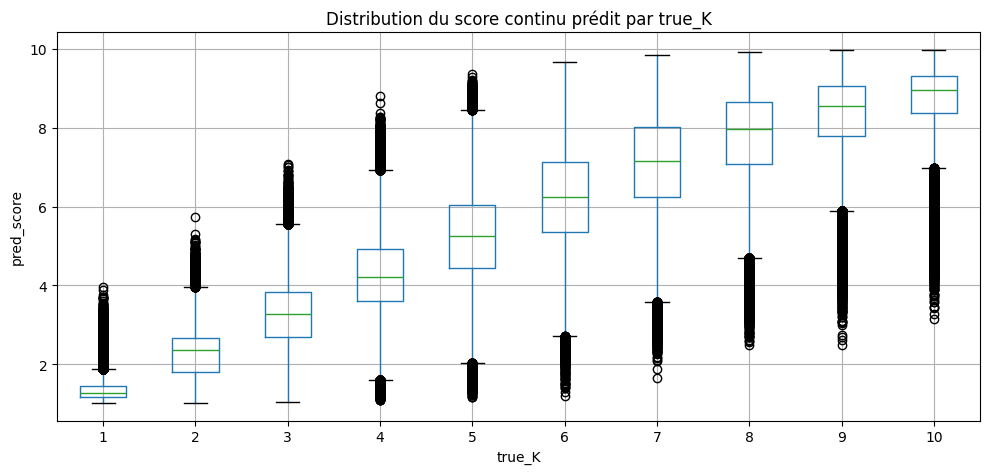

In [81]:
plt.figure(figsize=(10, 5))

df.boxplot(
    column="pred_score",
    by="true_K",
    grid=True,
    figsize=(10, 5),
)

plt.suptitle("")
plt.title("Distribution du score continu prédit par true_K")
plt.xlabel("true_K")
plt.ylabel("pred_score")
plt.tight_layout()
plt.show()

In [82]:
from sklearn.metrics import mean_absolute_error, accuracy_score

score = df["pred_score"].to_numpy()
true = df["true_K"].to_numpy()

pred_round = np.rint(score).clip(1, 10).astype(int)

print("Accuracy avec round(pred_score):", accuracy_score(true, pred_round))
print("MAE avec round(pred_score):", mean_absolute_error(true, pred_round))

Accuracy avec round(pred_score): 0.3899824142456055
MAE avec round(pred_score): 0.7998956680297852


In [83]:
from sklearn.metrics import accuracy_score, mean_absolute_error

score = df["pred_score"].to_numpy()
true = df["true_K"].to_numpy()

thresholds = []

for k in range(1, 10):
    s_left = score[true == k]
    s_right = score[true == k + 1]

    threshold = 0.5 * (np.median(s_left) + np.median(s_right))
    thresholds.append(threshold)

thresholds = np.asarray(thresholds)

pred_calibrated = 1 + (score[:, None] > thresholds[None, :]).sum(axis=1)
pred_calibrated = np.clip(pred_calibrated, 1, 10)

print("Thresholds:", thresholds)
print("Accuracy calibrated:", accuracy_score(true, pred_calibrated))
print("MAE calibrated:", mean_absolute_error(true, pred_calibrated))

Thresholds: [1.81519222 2.82103199 3.75026155 4.73270726 5.73677087 6.6993463
 7.56190038 8.25696635 8.75635529]
Accuracy calibrated: 0.4197221755981445
MAE calibrated: 0.8174221038818359
